In [ ]:
from pathlib import Path
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network
from gwfast.fisherTools import reduce_Fisher_matrix, CovMatr

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


## `Dls_wrt_y_and_R_orbit` definition

In [2]:
def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    # y has units of einstein radius, R_orbit has units of R_S
    return (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs

## Detector setup

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

## Parameters

In [ ]:
n = 3
shape = (n, n, n)
events = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.full(shape, val).astype(np.float64) for key, val in events.items()}

# Sample parameter space
dL_array = np.geomspace(0.2, 2, n) # Gpc
y_array = np.linspace(0.2, 2, n) # in Einstein radii
R_orbit_array = np.linspace(10, 1000, n)

dL_mesh, R_orbit_mesh, _ = np.meshgrid(dL_array, R_orbit_array, y_array, indexing='xy')
events['dL'] = dL_mesh
events['R_orbit'] = R_orbit_mesh

# Convert y to src_pos for injection
Dls_min = Dls_wrt_y_and_R_orbit(1, R_orbit_array) # for rs=1, this is in units of R_S
beta_max = np.sqrt(2 * Dls_min) # Maximum source position (i.e. Einstein radius) in units of R_S
betas = np.outer(y_array, beta_max / R_orbit_array)
events['src_pos'] = np.repeat(np.expand_dims(betas, axis=0), n, axis=0)

# Separate the events by distance
events_list = []
for i in range(n):
    events_temp = {key: val[i, :, :] for key, val in events.items()}
    events_list.append(events_temp)

## Compute SNR

In [5]:
SNR_base = HLV_AGN.SNR(events_list[0])
SNR_array = np.repeat(np.expand_dims(SNR_base, axis=0), n, axis=0)

dL_bcast = dL_array[:, np.newaxis, np.newaxis]
SNR_array = SNR_array * dL_array[0] / dL_bcast # Scale SNR inversely with distance

## Compute Fisher and Cov

In [6]:
reduced_fisher_list = []
reduced_cov_list = []
ie_list = []
for i in range(n):
    events = events_list[i]
    fisher = HLV_AGN.FisherMatr(events, res=1000)
    keys = list(events.keys()).copy()
    reduced_fisher, _ = reduce_Fisher_matrix(fisher, keys=keys)
    reduced_cov, ie = CovMatr(reduced_fisher)
    reduced_fisher_list.append(reduced_fisher)
    reduced_cov_list.append(reduced_cov)
    ie_list.append(ie)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 7.891522174092788, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 9.404191003259783, Maximum duration: 24.60698144251176.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolve

Text(0, 0.5, '$y\\,\\equiv\\,\\beta\\,/\\,\\theta_E$')

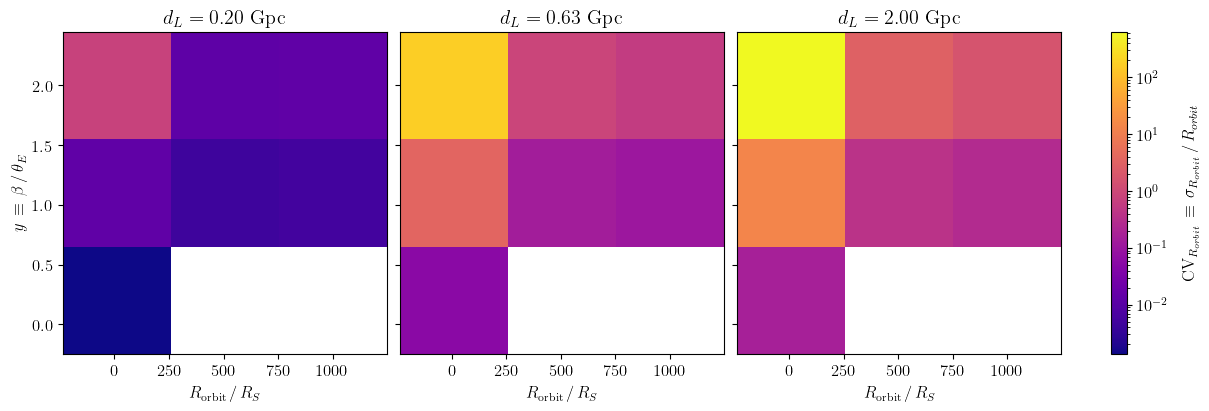

In [7]:
idx_R = 7

CV_R_list = []
for i in range(n):
   events = events_list[i]
   reduced_cov = reduced_cov_list[i]
   std_R = onp.sqrt(reduced_cov[idx_R, idx_R, :, :])
   CV_R = std_R / onp.asarray(events['R_orbit'])
   CV_R_list.append(CV_R)

vmin = onp.nanmin(CV_R_list)
vmax = onp.nanmax(CV_R_list)

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)
for i in range(3):
   ax = axs[i]
   im = ax.pcolormesh(R_orbit_array, y_array, CV_R_list[i], cmap='plasma',
                     norm=LogNorm(vmin=vmin, vmax=vmax)
                     )
   # ax.set_xscale('log')
   # ax.set_yscale('log')
   ax.set_xlabel(r'$R_{\rm orbit}\,/\,R_S$')
   ax.set_title(r'$d_L = {:.2f}$ Gpc'.format(dL_array[i]))

cbar = fig.colorbar(im, ax=axs)
cbar.set_label(r'${\rm CV}_{R_{orbit}}\,\equiv\,\sigma_{R_{orbit}}\,/\,R_{orbit}$', labelpad=10)
axs[0].set_ylabel(r'$y\,\equiv\,\beta\,/\,\theta_E$')

In [8]:
SNR_array

Array([[[255.47308335,          nan,          nan],
        [ 45.95965788,  89.74873851, 108.61137619],
        [ 14.39034583,  21.34167727,  24.93972477]],

       [[ 80.78768242,          nan,          nan],
        [ 14.53371994,  28.38104308,  34.34593286],
        [  4.55062691,   6.74883093,   7.88663345]],

       [[ 25.54730833,          nan,          nan],
        [  4.59596579,   8.97487385,  10.86113762],
        [  1.43903458,   2.13416773,   2.49397248]]], dtype=float64)